In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Exercice 1

On va réaliser une analyse statistique du [jeu de données Iris](https://www.kaggle.com/datasets/uciml/iris). Celui-ci contient 50 échantillons de chacune des trois espèces d'iris : Iris setosa, Iris virginica et Iris versicolor.  Quatre caractéristiques ont été mesurées pour chaque échantillon : la longueur et la largeur des sépales et des pétales, en centimètres.

On commence par importer le jeu de données.

In [2]:
from sklearn import datasets 

iris = datasets.load_iris(as_frame=True) # True si vous voulez un DataFrame pandas, False si vous voulez un np.array
X = iris.data  # données des 4 caractéristiques des fleurs
X.columns = ["sepal_l", "sepal_w", "petal_l", "petal_w"] # formatage des noms des colonnes
y = iris.target  # labels du type de fleur pour chaque instance

Affichez quelques exemples :

In [3]:
#TODO
print(X.head()) 

   sepal_l  sepal_w  petal_l  petal_w
0      5.1      3.5      1.4      0.2
1      4.9      3.0      1.4      0.2
2      4.7      3.2      1.3      0.2
3      4.6      3.1      1.5      0.2
4      5.0      3.6      1.4      0.2


Affichez maintenant le nombre d'éléments du jeu de données :

In [4]:
#TODO
print(X.shape)

(150, 4)


 Créea un nouveau DataFrame dans une variable `X0`, qui prend en compte seulement les individus appartenant à la classe `y = 0` (Iris Setosa).

In [5]:
#TODO
X0 = X[y == 0]

Calculez et affichez les valeurs des statistiques de base pour les variables `sepal_l` et `sepal w` du jeu de données `X0`: moyenne, mode, médiane et écart-type.

In [6]:
#TODO moyenne
print(X0[["sepal_l", "sepal_w"]].mean())

sepal_l    5.006
sepal_w    3.428
dtype: float64


In [7]:
#TODO mode
print(X0[["sepal_l", "sepal_w"]].mode())

   sepal_l  sepal_w
0      5.0      3.4
1      5.1      NaN


In [8]:
#TODO médiane
print(X0[["sepal_l", "sepal_w"]].median())

sepal_l    5.0
sepal_w    3.4
dtype: float64


In [9]:
#TODO écart-type
print(X0[["sepal_l", "sepal_w"]].std())

sepal_l    0.352490
sepal_w    0.379064
dtype: float64


Refaites la même chose pour les individus de la classe `y==1` (Iris Virginica) en stockant les données dans un jeu de données `X1`.
Est-ce que vous remarquez des différences par rapport au type de Iris précédent? Pouvez vous tirer des conclusions?

In [10]:
#TODO
X1 = X[y == 1]

Pour les fleurs Iris Setosa et Iris Virginica, faites aussi le calcul des quartiles pour la variable `sepal_l`. 

In [11]:
#TODO
print("Quartiles X0 sepal_l:")
print(X0["sepal_l"].quantile([0.25, 0.5, 0.75]))
print("\nQuartiles X1 sepal_w:")
print(X1["sepal_w"].quantile([0.25, 0.5, 0.75]))

Quartiles X0 sepal_l:
0.25    4.8
0.50    5.0
0.75    5.2
Name: sepal_l, dtype: float64

Quartiles X1 sepal_w:
0.25    2.525
0.50    2.800
0.75    3.000
Name: sepal_w, dtype: float64


Affichez l'histogramme de cette variable et rajoutez-y des lignes verticales pour la moyenne, le mode, la mediane et les quartiles. Observe- vous des différences ou des similarités ?

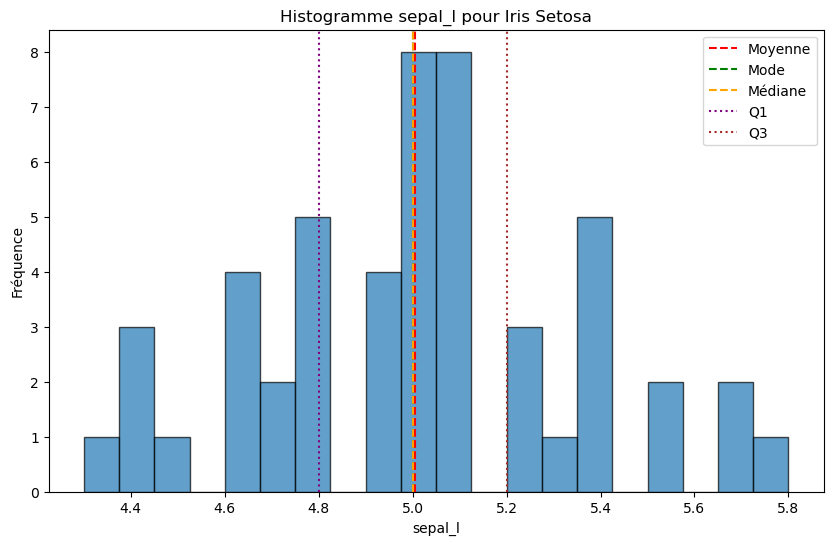

In [12]:
#TODO
plt.figure(figsize=(10, 6))
plt.hist(X0["sepal_l"], bins=20, alpha=0.7, edgecolor='black')
plt.axvline(X0["sepal_l"].mean(), color='red', linestyle='--', label='Moyenne')
plt.axvline(X0["sepal_l"].mode()[0], color='green', linestyle='--', label='Mode')
plt.axvline(X0["sepal_l"].median(), color='orange', linestyle='--', label='Médiane')
plt.axvline(X0["sepal_l"].quantile(0.25), color='purple', linestyle=':', label='Q1')
plt.axvline(X0["sepal_l"].quantile(0.75), color='brown', linestyle=':', label='Q3')
plt.legend()
plt.xlabel('sepal_l')
plt.ylabel('Fréquence')
plt.title('Histogramme sepal_l pour Iris Setosa')
plt.show()

Pour les variables `sepal_l` et `sepal_w` du dataset `X0`, calculez le degré de corrélation linéaire.  Visualisez le résultat l'aide d'un `scatterplot`.

Corrélation: 0.7425466856651597


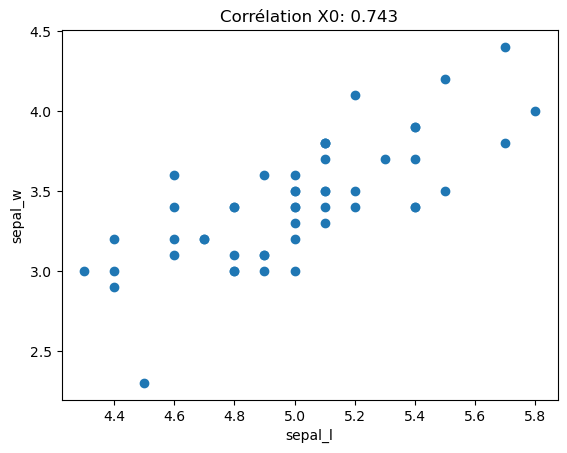

In [13]:
#TODO
corr = X0["sepal_l"].corr(X0["sepal_w"])
print(f"Corrélation: {corr}")
plt.scatter(X0["sepal_l"], X0["sepal_w"])
plt.xlabel('sepal_l')
plt.ylabel('sepal_w')
plt.title(f'Corrélation X0: {corr:.3f}')
plt.show()

Dans le jeu de données complet `X`, visualisez si les trois classes de fleurs sont visuellement séparées sur un `scatterplot` utilisant les variables `sepal_l` et `sepal_w`. 
Notons que, le cas échéant, il serait assez simple de construire un modèle de classification d'Iris utilisant ces deux variables.

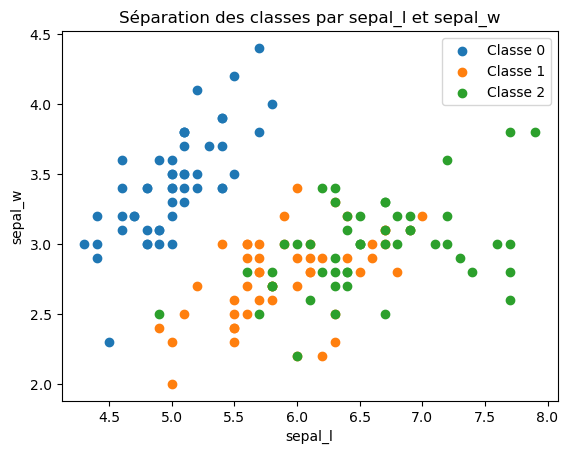

In [14]:
#TODO
for cls in range(3):
    mask = y == cls
    plt.scatter(X[mask]["sepal_l"], X[mask]["sepal_w"], label=f'Classe {cls}')
plt.xlabel('sepal_l')
plt.ylabel('sepal_w')
plt.legend()
plt.title('Séparation des classes par sepal_l et sepal_w')
plt.show()

Entraînez une PCA sur le jeu de données complet `X` afin de réduire sa dimension à deux composantes principales.

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

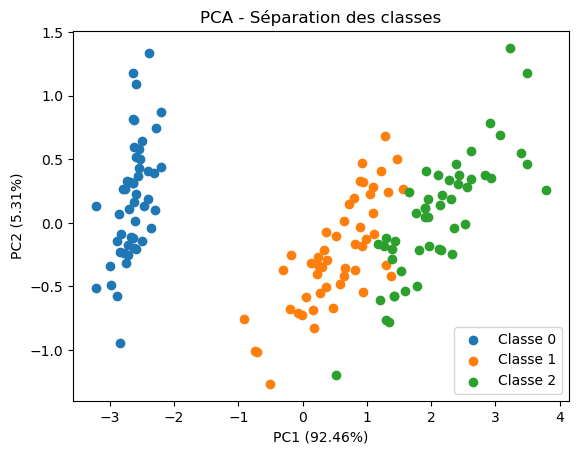

In [16]:
#TODO
for cls in range(3):
    mask = y == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Classe {cls}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend()
plt.title('PCA - Séparation des classes')
plt.show()

Visualisez si les trois classes sont séparées dans un `scatterplot`.

In [17]:
#TODO

# Exercice 2

Dans cet exercice, nous allons analyser un mini jeu de données d'enquête d'affiliation politique. Suite à l'enquête, des données de tranche d'âge (18-29 ans, 30-44, 45-65 et 65+) et d'affiliation politique (droite, gauche ou autre) ont été recoltées pour 1189 individus du pays "Politiville". Nous souhaitons déterminer s'il existe un lien entre l'âge et l'affiliation politique.

In [18]:
# create sample data according to survey
data = [['18-29', 'Conservative'] for i in range(141)] + \
        [['18-29', 'Socialist'] for i in range(68)] + \
        [['18-29', 'Other'] for i in range(4)] + \
        [['30-44', 'Conservative'] for i in range(179)] + \
        [['30-44', 'Socialist'] for i in range(159)] + \
        [['30-44', 'Other'] for i in range(7)] + \
        [['45-65', 'Conservative'] for i in range(220)] + \
        [['45-65', 'Socialist'] for i in range(216)] + \
        [['45-65', 'Other'] for i in range(4)] + \
        [['65 & older', 'Conservative'] for i in range(86)] + \
        [['65 & older', 'Socialist'] for i in range(101)] + \
        [['65 & older', 'Other'] for i in range(4)]

df = pd.DataFrame(data, columns = ['Age Group', 'Political Affiliation']) 
df.head()

,Age Group,Political Affiliation
0,18-29,Conservative
1,18-29,Conservative
2,18-29,Conservative
3,18-29,Conservative
4,18-29,Conservative


In [19]:
df.shape

(1189, 2)

On crée et stocke dans une variable `data_crosstabl` le tableau de contingence en utilisant `pandas.crosstab` avec `margins=True` pour calculer les totaux :

In [20]:
# create contingency table
data_crosstab = pd.crosstab(
    df['Age Group'],
    df['Political Affiliation'],
    margins=True,
    margins_name="Total"
)

data_crosstab

Political Affiliation,Conservative,Other,Socialist,Total
Age Group,,,,
18-29,141,4,68,213
30-44,179,7,159,345
45-65,220,4,216,440
65 & older,86,4,101,191
Total,626,19,544,1189


Faisons le test du $\chi^2$ en utilisant la formule vue en cours.

Commencez par calculer et stocker dans une variable `chi_square` le $\chi^2$ observé.

In [21]:
#TODO
# Tableau de contingence sans marges
contingency_table = pd.crosstab(df['Age Group'], df['Political Affiliation'])

# Fréquences observées
observed = contingency_table.values

# Calcul des fréquences théoriques (attendues)
row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)
total = observed.sum()

expected = np.outer(row_totals, col_totals) / total

# Calcul du chi-square observé
chi_square = np.sum((observed - expected)**2 / expected)
print(f"Chi-square observé: {chi_square:.4f}")

Chi-square observé: 24.3674


Comparez cette valeur avec le $\chi^2_a$ critique en utilisant la fonction `ppf` du package `scipy`.

In [22]:
import scipy.stats as stats

alpha = 0.05
dof = (contingency_table.shape[0] - 1) * (contingency_table.shape[1] - 1)
critical_chi_square = stats.chi2.ppf(1-alpha, dof)

# Comparaison
print(f"Chi-square observé: {chi_square:.4f}")
print(f"Chi-square critique: {critical_chi_square:.4f}")

if chi_square > critical_chi_square:
    print(f"Résultat significatif: On rejette H0 (l'âge et l'affiliation ne sont pas indépendantes)")
else:
    print(f"Résultat non significatif: On accepte H0 (l'âge et l'affiliation sont indépendantes)")


Chi-square observé: 24.3674
Chi-square critique: 12.5916
Résultat significatif: On rejette H0 (l'âge et l'affiliation ne sont pas indépendantes)


On peut directement utiliser la fonction `chi2_contingency`. Cependant, le tableau de contingence ne doit pas contenir les marges dans ce cas !

In [23]:
from scipy.stats import chi2_contingency

data_crosstab = pd.crosstab(
    df['Age Group'],
    df['Political Affiliation'],
    margins=False
)

chi_square, p_value, dof, expected = chi2_contingency(data_crosstab)

print(f"Le chi2 est {chi_square} et la p_value est {p_value}")

# p_value habituelle
alpha = 0.05

if p_value < alpha:
    conclusion = f"La p-value ({p_value:.4f}) est < {alpha}. On rejette l'hypothèse nulle : l'âge et l'affiliation ne sont pas indépendantes."
else:
    conclusion = f"La p-value ({p_value:.4f}) est > {alpha}. Le résultat n'est pas statistiquement significatif."
    
print(conclusion)

Le chi2 est 24.367421717305206 et la p_value est 0.00044690833914947634
La p-value (0.0004) est < 0.05. On rejette l'hypothèse nulle : l'âge et l'affiliation ne sont pas indépendantes.


# Exercice 3

In [24]:
import kagglehub
from pathlib import Path

# Download latest version
path = kagglehub.dataset_download("semaaabumousa/athlete-eventscsv")

print("Path to dataset files:", Path(path)/'athlete_events.csv')

df = pd.read_csv(Path(path)/'athlete_events.csv')
df.head(10)

c:\Users\benoi\miniconda3\envs\ml\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


100%|██████████| 5.43M/5.43M [00:00<00:00, 8.68MB/s]

Extracting files...


Path to dataset files: C:\Users\benoi\.cache\kagglehub\datasets\semaaabumousa\athlete-eventscsv\versions\1\athlete_events.csv


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",NaN


Vérifiez à l’aide d’un histogramme quel est le sport le plus représenté dans le jeu de données.

Sport le plus représenté: Athletics avec 38624 occurrences


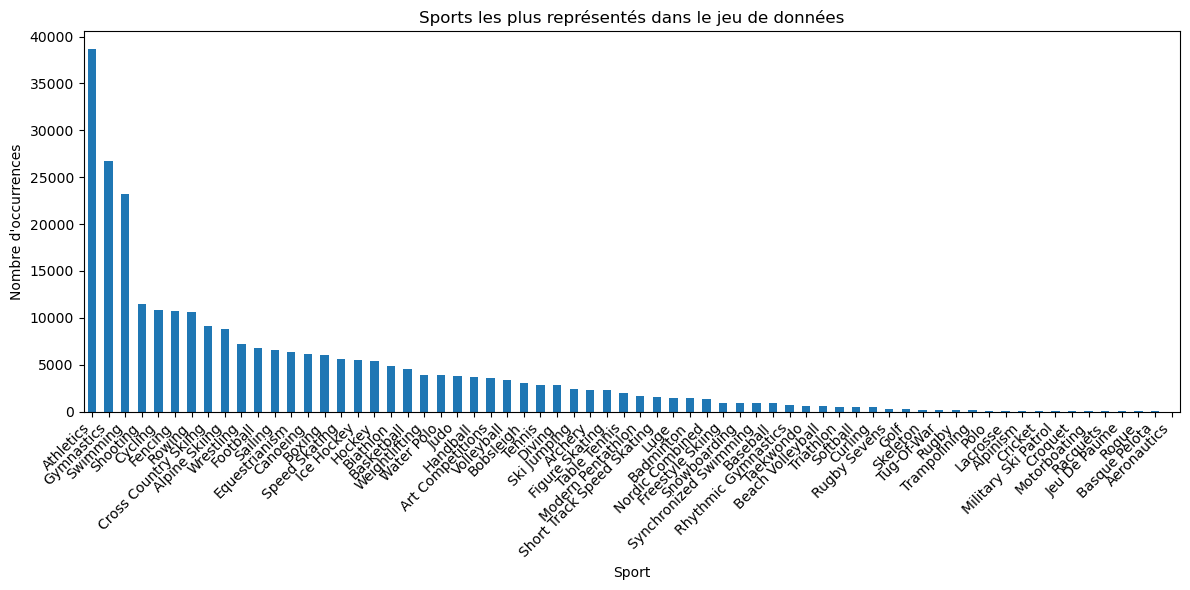

In [27]:
#TODO
# Compter les occurrences de chaque sport
sport_counts = df['Sport'].value_counts()

# Afficher le sport le plus représenté
print(f"Sport le plus représenté: {sport_counts.index[0]} avec {sport_counts.iloc[0]} occurrences")

# Créer un histogramme
plt.figure(figsize=(12, 6))
sport_counts.plot(kind='bar')
plt.xlabel('Sport')
plt.ylabel('Nombre d\'occurrences')
plt.title('Sports les plus représentés dans le jeu de données')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Pour le sport le plus représenté :

* Calculez moyenne, mode, médiane, quartiles, écart-type et variance des variables numériques (`Height`, `Weight`, `Age`).
* Affichez l'histogramme avec moyenne, mode et médiane.
* Refaites le même exercice en séparant et comparant les quantités pour les sous-populations d’hommes et femmes. Remarquez-vous des choses intéressantes à partir de ces statistiques ?
* Vérifiez le degré de corrélation linéaire entre les variables numériques. Est-ce que vous pouvez essayer de conclure quelque chose sur des possibles liens de causalité ?
* Prenez les individus de sexe `M` (car il y a plus de données, mais vous pouvez également choisir `F`) ayant gagné une médaille. Faites une PCA sur les variables `Age`, `Weight`, `Height`. Via un `scatterplot`, visualisez si on peut séparer les groupes correspondants aux différentes médailles sur les deux premiers axes principaux.

Analyse pour le sport: Athletics
Nombre d'occurrences: 38624

STATISTIQUES GLOBALES (tous les athlètes du sport)

Height:
  Moyenne: 176.26
  Mode: 180.0
  Médiane: 176.00
  Q1: 170.00, Q3: 183.00
  Écart-type: 9.31
  Variance: 86.76

Weight:
  Moyenne: 69.25
  Mode: 70.0
  Médiane: 67.00
  Q1: 59.00, Q3: 76.00
  Écart-type: 15.39
  Variance: 236.97

Age:
  Moyenne: 25.16
  Mode: 23.0
  Médiane: 25.00
  Q1: 22.00, Q3: 28.00
  Écart-type: 4.40
  Variance: 19.34


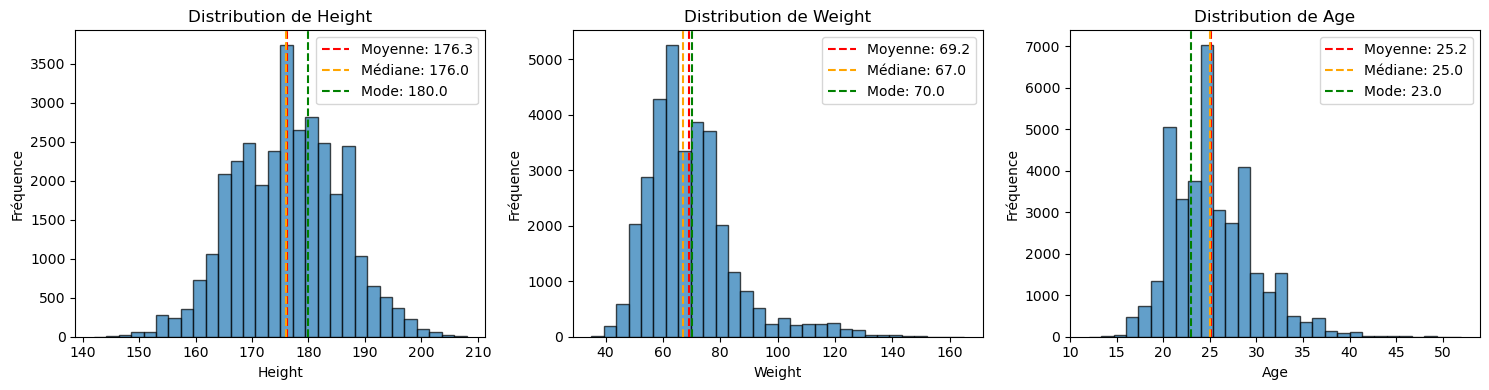


COMPARAISON PAR SEXE

--- SEXE: M (n=26958) ---

Height:
  Moyenne: 179.77
  Médiane: 180.00
  Écart-type: 8.14

Weight:
  Moyenne: 73.84
  Médiane: 71.00
  Écart-type: 15.07

Age:
  Moyenne: 25.26
  Médiane: 25.00
  Écart-type: 4.27

--- SEXE: F (n=11666) ---

Height:
  Moyenne: 169.29
  Médiane: 169.00
  Écart-type: 7.37

Weight:
  Moyenne: 60.24
  Médiane: 58.00
  Écart-type: 11.58

Age:
  Moyenne: 24.93
  Médiane: 24.00
  Écart-type: 4.66


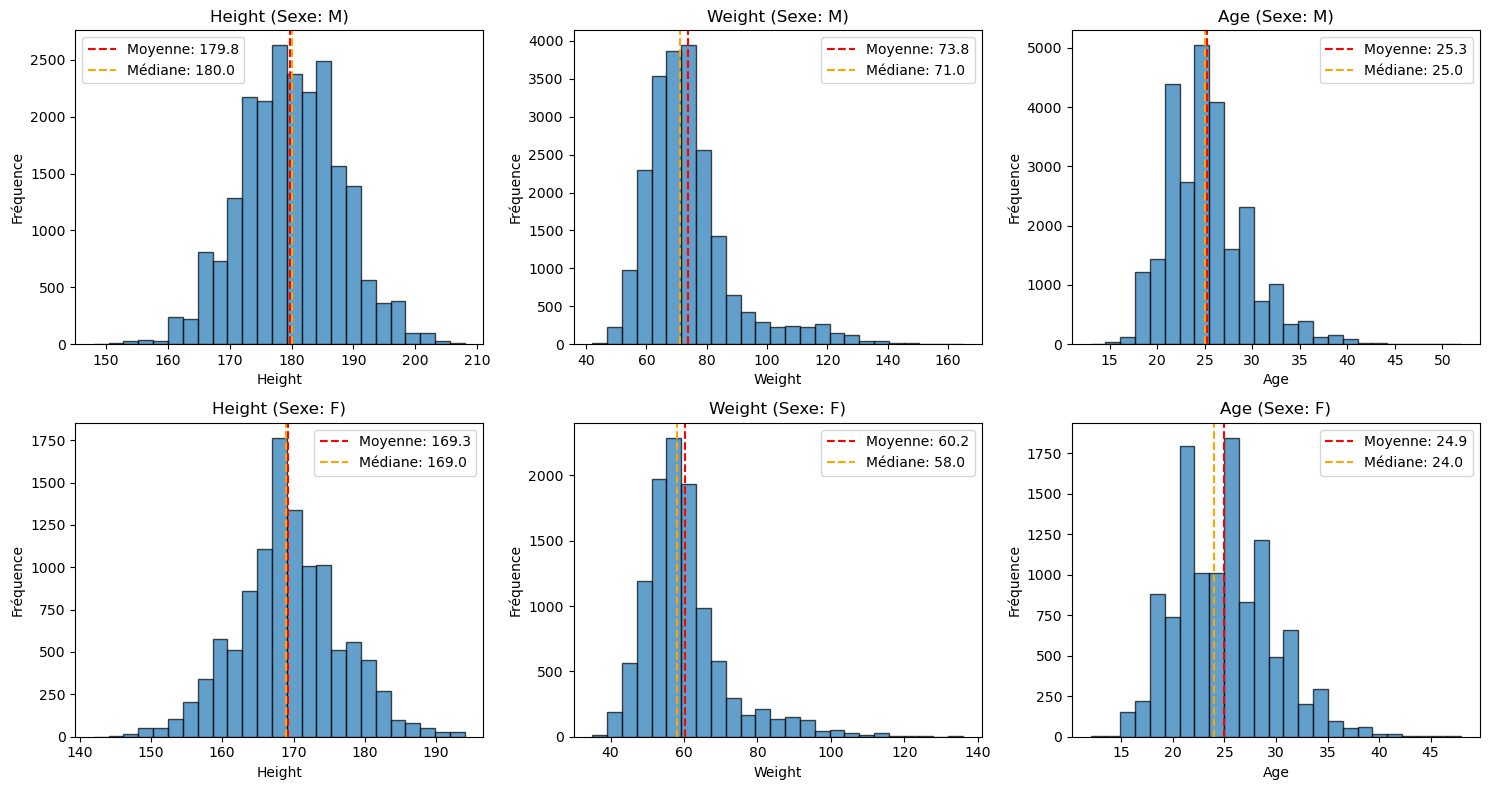


CORRÉLATION LINÉAIRE

Matrice de corrélation:
          Height    Weight       Age
Height  1.000000  0.753208  0.012263
Weight  0.753208  1.000000  0.065833
Age     0.012263  0.065833  1.000000


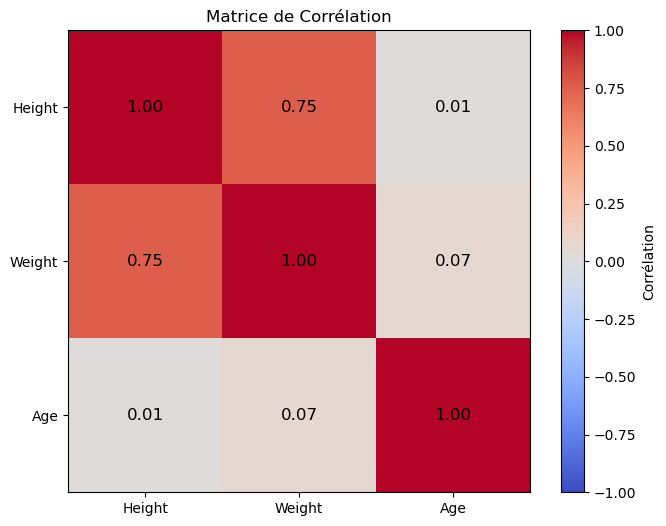


PCA - ATHLÈTES MASCULINS AVEC MÉDAILLES
Nombre d'athlètes M avec médaille: 2409
Médailles: ['Bronze' 'Gold' 'Silver']

Variance expliquée:
  PC1: 57.24%
  PC2: 33.33%
  Total: 90.57%


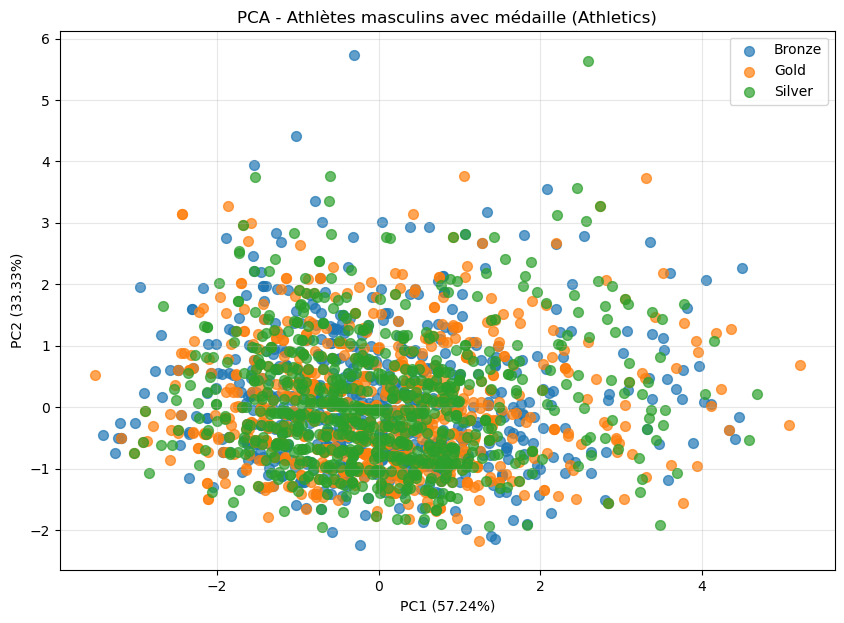

In [28]:
#TODO
# Filtrer le dataset pour le sport le plus représenté
most_common_sport = df['Sport'].value_counts().index[0]
df_sport = df[df['Sport'] == most_common_sport].copy()

print(f"Analyse pour le sport: {most_common_sport}")
print(f"Nombre d'occurrences: {len(df_sport)}\n")

# 1. Statistiques descriptives pour Height, Weight, Age
print("=" * 60)
print("STATISTIQUES GLOBALES (tous les athlètes du sport)")
print("=" * 60)

for var in ['Height', 'Weight', 'Age']:
    print(f"\n{var}:")
    data_var = df_sport[var].dropna()
    print(f"  Moyenne: {data_var.mean():.2f}")
    print(f"  Mode: {data_var.mode().values[0] if len(data_var.mode()) > 0 else 'N/A'}")
    print(f"  Médiane: {data_var.median():.2f}")
    print(f"  Q1: {data_var.quantile(0.25):.2f}, Q3: {data_var.quantile(0.75):.2f}")
    print(f"  Écart-type: {data_var.std():.2f}")
    print(f"  Variance: {data_var.var():.2f}")

# 2. Histogrammes avec moyenne, mode, médiane
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, var in enumerate(['Height', 'Weight', 'Age']):
    data_var = df_sport[var].dropna()
    axes[idx].hist(data_var, bins=30, alpha=0.7, edgecolor='black')
    
    mean_val = data_var.mean()
    median_val = data_var.median()
    mode_val = data_var.mode().values[0] if len(data_var.mode()) > 0 else None
    
    axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Moyenne: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='orange', linestyle='--', label=f'Médiane: {median_val:.1f}')
    if mode_val:
        axes[idx].axvline(mode_val, color='green', linestyle='--', label=f'Mode: {mode_val:.1f}')
    
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Fréquence')
    axes[idx].set_title(f'Distribution de {var}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# 3. Séparation par sexe (M vs F)
print("\n" + "=" * 60)
print("COMPARAISON PAR SEXE")
print("=" * 60)

for sex in ['M', 'F']:
    df_sex = df_sport[df_sport['Sex'] == sex].copy()
    if len(df_sex) == 0:
        print(f"\nPas de données pour le sexe {sex}")
        continue
    
    print(f"\n--- SEXE: {sex} (n={len(df_sex)}) ---")
    for var in ['Height', 'Weight', 'Age']:
        data_var = df_sex[var].dropna()
        if len(data_var) > 0:
            print(f"\n{var}:")
            print(f"  Moyenne: {data_var.mean():.2f}")
            print(f"  Médiane: {data_var.median():.2f}")
            print(f"  Écart-type: {data_var.std():.2f}")

# Histogrammes comparatifs par sexe
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, var in enumerate(['Height', 'Weight', 'Age']):
    for sex_idx, sex in enumerate(['M', 'F']):
        df_sex = df_sport[df_sport['Sex'] == sex]
        data_var = df_sex[var].dropna()
        
        if len(data_var) > 0:
            axes[sex_idx, idx].hist(data_var, bins=25, alpha=0.7, edgecolor='black')
            axes[sex_idx, idx].axvline(data_var.mean(), color='red', linestyle='--', label=f'Moyenne: {data_var.mean():.1f}')
            axes[sex_idx, idx].axvline(data_var.median(), color='orange', linestyle='--', label=f'Médiane: {data_var.median():.1f}')
            axes[sex_idx, idx].set_title(f'{var} (Sexe: {sex})')
            axes[sex_idx, idx].set_xlabel(var)
            axes[sex_idx, idx].set_ylabel('Fréquence')
            axes[sex_idx, idx].legend()

plt.tight_layout()
plt.show()

# 4. Corrélation linéaire entre variables numériques
print("\n" + "=" * 60)
print("CORRÉLATION LINÉAIRE")
print("=" * 60)

df_numeric = df_sport[['Height', 'Weight', 'Age']].dropna()
correlation_matrix = df_numeric.corr()

print("\nMatrice de corrélation:")
print(correlation_matrix)

# Heatmap de corrélation
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Corrélation')
plt.xticks([0, 1, 2], ['Height', 'Weight', 'Age'])
plt.yticks([0, 1, 2], ['Height', 'Weight', 'Age'])
plt.title('Matrice de Corrélation')
for i in range(3):
    for j in range(3):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', color='black', fontsize=12)
plt.show()

# 5. PCA pour athlètes M avec médailles
print("\n" + "=" * 60)
print("PCA - ATHLÈTES MASCULINS AVEC MÉDAILLES")
print("=" * 60)

from sklearn.preprocessing import StandardScaler

# Filtrer athlètes M avec médaille
df_medal = df_sport[(df_sport['Sex'] == 'M') & (df_sport['Medal'].notna())].copy()
df_medal = df_medal[['Age', 'Weight', 'Height', 'Medal']].dropna()

if len(df_medal) > 0:
    print(f"Nombre d'athlètes M avec médaille: {len(df_medal)}")
    print(f"Médailles: {df_medal['Medal'].unique()}")
    
    # Normaliser les données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_medal[['Age', 'Weight', 'Height']])
    
    # PCA
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"\nVariance expliquée:")
    print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
    print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
    print(f"  Total: {pca.explained_variance_ratio_.sum():.2%}")
    
    # Scatterplot
    plt.figure(figsize=(10, 7))
    for medal in df_medal['Medal'].unique():
        mask = df_medal['Medal'] == medal
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=medal, s=50, alpha=0.7)
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.title(f'PCA - Athlètes masculins avec médaille ({most_common_sport})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Pas d'athlètes masculins avec médaille pour ce sport")
